##**CUNY SPS - DATA 620: Web Analytics**

##**Week 6 Assignment: Davis Southern Women Network**

##**Brandon Chanderban**

##**Dataset Description**
The Davis Southern Women dataset documents the attendance of 18 women at 14 social events, originating from a 1941 study. Represented via a bipartite network, the dataset comprises 32 nodes and 89 edges, illustrating the attendance relationships between the women and their respective social events.

##**Objective of the Analysis**

This analysis seeks to examine the relationships amongst the women and social events by identifying shared attendance patterns, prominent connections, and potential social groupings through network and quantitative measures.


##1. Loading and Exploring the Dataset

The Davis Southern Women dataset is imported using NetworkX, followed by an examination of its basic network properties and constituent node sets.

In [1]:
# Import the required libraries.
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

# Load the Davis Southern Women dataset.
G = nx.davis_southern_women_graph()

# Identify the two node sets.
women = G.graph["top"]
events = G.graph["bottom"]

# Display the network's basic properties.
print(f"There are {len(women)} women within the network.")
print(f"There are {len(events)} social events within the network.")
print(f"There are {G.number_of_nodes()} total nodes.")
print(f"The total number of edges/attendance relationships is {G.number_of_edges()}.")
print("Is this network bipartite?", bipartite.is_bipartite(G))

There are 18 women within the network.
There are 14 social events within the network.
There are 32 total nodes.
The total number of edges/attendance relationships is 89.
Is this network bipartite? True


##2. Visualizing the Bipartite Network

The following visualization illustrates the attendance relationships between the 18 women and 14 social events, with each edge representing a recorded instance of attendance.

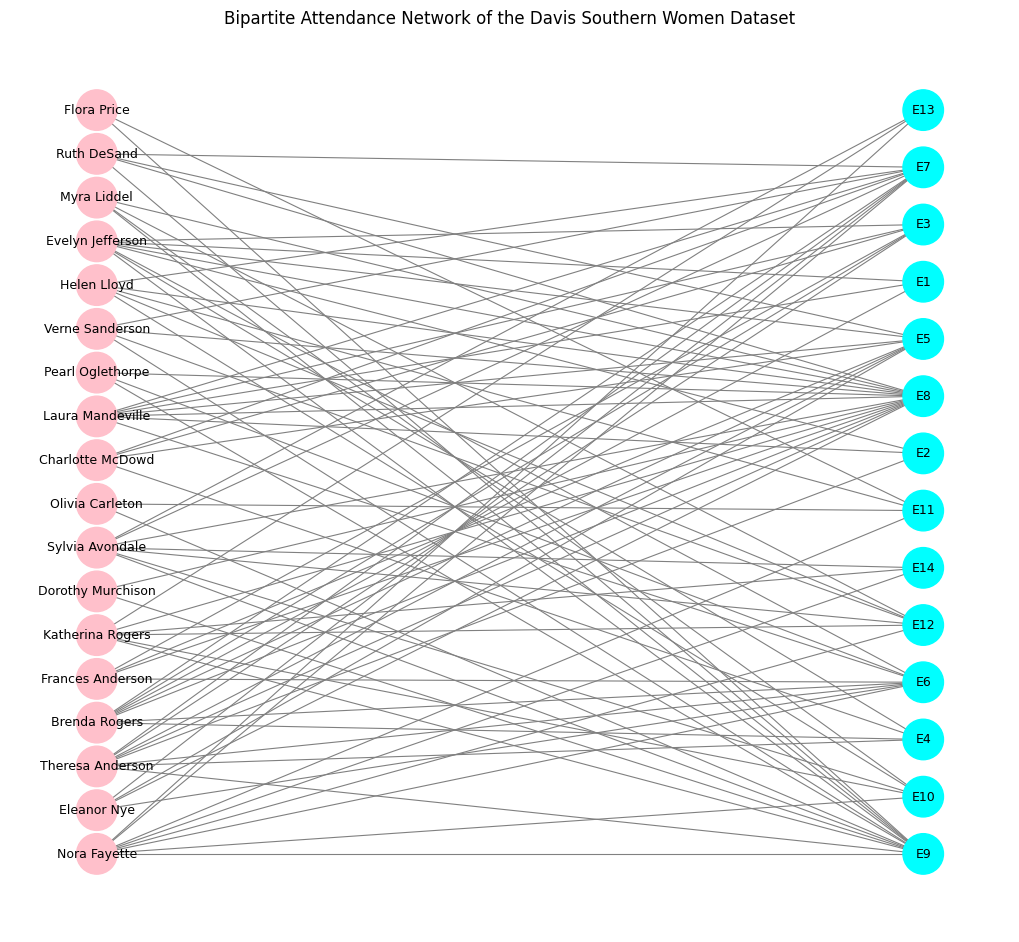

In [2]:
# Establish a bipartite layout for the network.
pos = nx.bipartite_layout(G, women)

# Assign different colors to each of the node sets.
node_colors = [
    "pink" if node in women else "cyan"
    for node in G.nodes()
]

# Visualize the original bipartite network.
plt.figure(figsize=(10,9))

nx.draw(
    G,
    pos,
    with_labels = True,
    node_color = node_colors,
    node_size = 850,
    font_size = 9,
    edge_color = "gray",
    width = 0.8
)

plt.title("Bipartite Attendance Network of the Davis Southern Women Dataset")
plt.show()

###Interpretation

The visualization above illustrates the attendance relationships between the 18 women (pink nodes) and 14 social events (cyan nodes). The numerous overlapping connections suggest several women attended common events, indicating potential patterns of shared social participation. However, further analysis is required so as to determine the strength of these relationships and identify possible social groupings.

##3. Examining the Attendance Patterns

The degree of each node is examined in order to identify the women attending the greatest number of events as well as the social events attracting the most participants.

In [3]:
# Calculate the number of events attended by each woman.
women_attendance = sorted(
    [(woman, G.degree(woman)) for woman in women],
    key = lambda x: x[1],
    reverse = True
)

# Calculate the number of women attending each event.
event_attendance = sorted(
    [(event, G.degree(event)) for event in events],
    key = lambda x: x[1],
    reverse = True
)

# Display attendance patterns.
print("Events Attended by Each Woman:")
for woman, count in women_attendance:
  print(f"{woman}: {count}")

print("\nNumber of Women Attending Each Event:")
for event, count in event_attendance:
  print(f"{event}: {count}")

Events Attended by Each Woman:
Evelyn Jefferson: 8
Theresa Anderson: 8
Nora Fayette: 8
Laura Mandeville: 7
Brenda Rogers: 7
Sylvia Avondale: 7
Katherina Rogers: 6
Helen Lloyd: 5
Charlotte McDowd: 4
Frances Anderson: 4
Eleanor Nye: 4
Ruth DeSand: 4
Verne Sanderson: 4
Myra Liddel: 4
Pearl Oglethorpe: 3
Dorothy Murchison: 2
Olivia Carleton: 2
Flora Price: 2

Number of Women Attending Each Event:
E8: 14
E9: 12
E7: 10
E5: 8
E6: 8
E3: 6
E12: 6
E10: 5
E4: 4
E11: 4
E1: 3
E2: 3
E13: 3
E14: 3


### Interpretation

Evelyn Jefferson, Theresa Anderson, and Nora Fayette recorded the highest participation, each attending 8 social events. Conversely, Dorothy Murchison, Olivia Carleton, and Flora Price attended the fewest, with 2 events each. Amongst the social events, E8 attracted the greatest attendance (14 women), followed by E9 (12) and E7 (10). These findings suggest that certain women were more actively involved in the network, whilst particular events provided greater opportunities for shared social participation.

##4. Examining the Relationships Amongst the Women

A weighted projection of the bipartite network is constructed to examine shared attendance amongst the women. Each edge represents at least one commonly attended event, whilst its weight indicates the total number of events shared by the corresponding pair.

In [4]:
# Project the bipartite network onto the women, retaining shared attendance counts.
W = bipartite.weighted_projected_graph(G, women)

# Examine the projected network's basic properties.
print("Number of women:", W.number_of_nodes())
print("Number of shared-attendance connections:", W.number_of_edges())
print("Network density:", round(nx.density(W), 3))

# Identify the pairs of women with the greatest shared attendance.
shared_attendance = sorted(
    W.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

print("\nTop 10 Pairs of Women by Shared Event Attendance:")
for woman1, woman2, data in shared_attendance[:10]:
    print(f"{woman1} and {woman2}: {data['weight']} shared events")

Number of women: 18
Number of shared-attendance connections: 139
Network density: 0.908

Top 10 Pairs of Women by Shared Event Attendance:
Evelyn Jefferson and Theresa Anderson: 7 shared events
Evelyn Jefferson and Brenda Rogers: 6 shared events
Evelyn Jefferson and Laura Mandeville: 6 shared events
Laura Mandeville and Brenda Rogers: 6 shared events
Laura Mandeville and Theresa Anderson: 6 shared events
Theresa Anderson and Brenda Rogers: 6 shared events
Katherina Rogers and Sylvia Avondale: 6 shared events
Sylvia Avondale and Nora Fayette: 6 shared events
Katherina Rogers and Nora Fayette: 5 shared events
Evelyn Jefferson and Frances Anderson: 4 shared events


### Interpretation

The projected network exhibits a high density of 0.908, indicating that approximately 90.8% of all possible pairs of women shared attendance at least once. Evelyn Jefferson and Theresa Anderson recorded the strongest shared-attendance connection, participating in 7 common events. Several other pairs also exhibited substantial overlap, suggesting a highly interconnected social network. Nevertheless, shared attendance does not necessarily establish direct friendships between participants.

##Visualizing the Relationships Amongst the Women

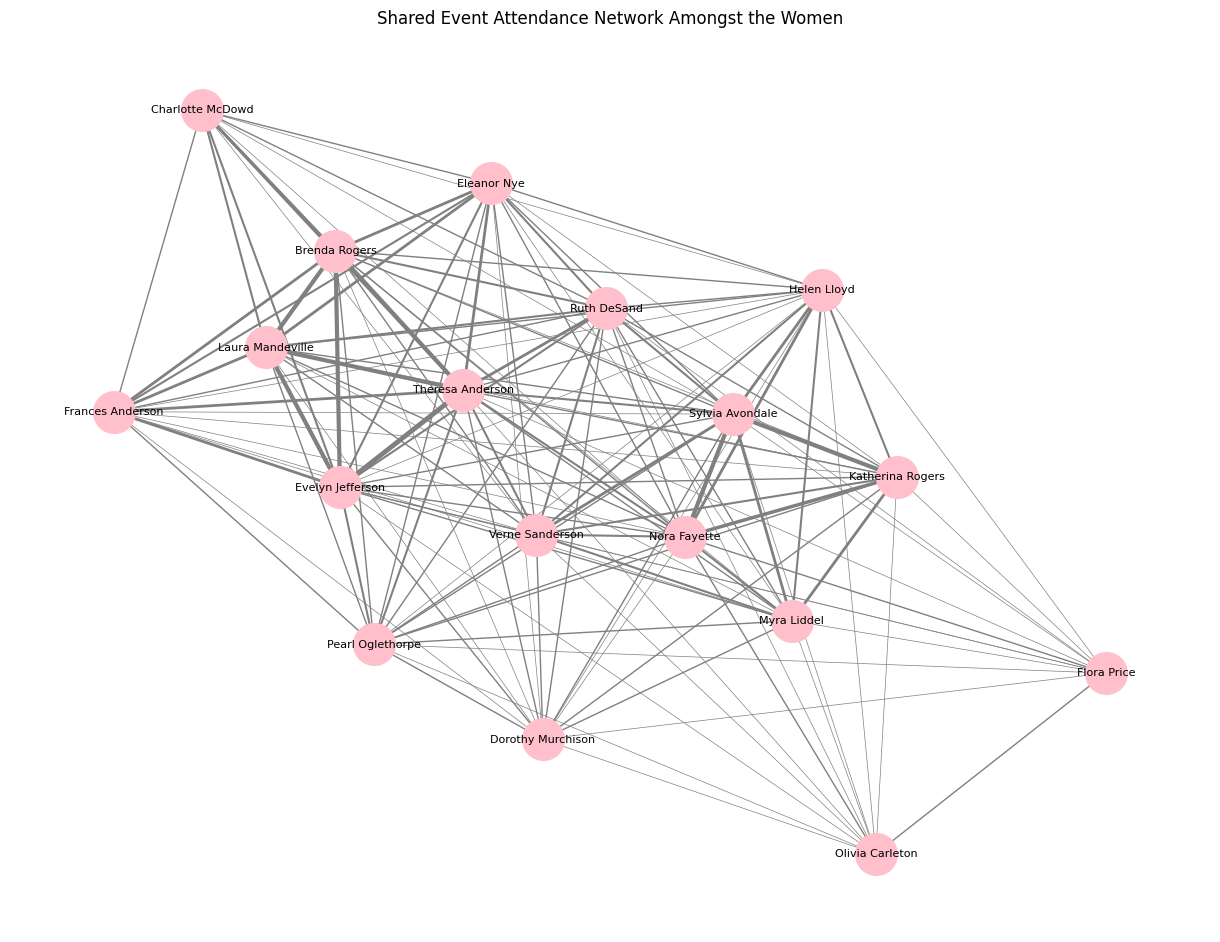

In [5]:
# Establish a reproducible layout for the women's projected network.
pos_women = nx.spring_layout(W, seed=6767)

# Assign edge widths based on the number of shared events.
edge_weights = [W[u][v]["weight"] for u, v in W.edges()]

# Visualize the women-to-women network.
plt.figure(figsize=(12, 9))

nx.draw(
    W,
    pos_women,
    with_labels=True,
    node_color="pink",
    node_size=900,
    font_size=8,
    edge_color="gray",
    width=[weight * 0.5 for weight in edge_weights]
)

plt.title("Shared Event Attendance Network Amongst the Women")
plt.show()

##5. Examining Relationships Amongst the Social Events

A weighted projection of the bipartite network is constructed to examine the relationships amongst social events based upon overlapping attendance. Each connection represents events attended by at least one common participant, whilst its weight indicates the number of attendees shared between them.

In [6]:
# Project the bipartite network onto the social events.
E = bipartite.weighted_projected_graph(G, events)

# Examine the basic properties of the projected network.
print(f"There are {E.number_of_nodes()} social events.")
print(f"There are {E.number_of_edges()} shared attendance connections.")
print(f"The network density is {round(nx.density(E), 3)}.")

# Identify the event pairs with the greatest attendance overlap.
shared_events = sorted(
    E.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

print("\nTop 10 Event Pairs by Shared Participants:")
for event1, event2, data in shared_events[:10]:
    print(f"{event1} and {event2}: {data['weight']} shared attendees.")

There are 14 social events.
There are 66 shared attendance connections.
The network density is 0.725.

Top 10 Event Pairs by Shared Participants:
E8 and E9: 9 shared attendees.
E7 and E8: 8 shared attendees.
E5 and E8: 7 shared attendees.
E6 and E8: 7 shared attendees.
E3 and E5: 6 shared attendees.
E5 and E6: 6 shared attendees.
E5 and E7: 6 shared attendees.
E3 and E6: 5 shared attendees.
E3 and E8: 5 shared attendees.
E6 and E7: 5 shared attendees.


##Visualizing the Event-to-Event Network

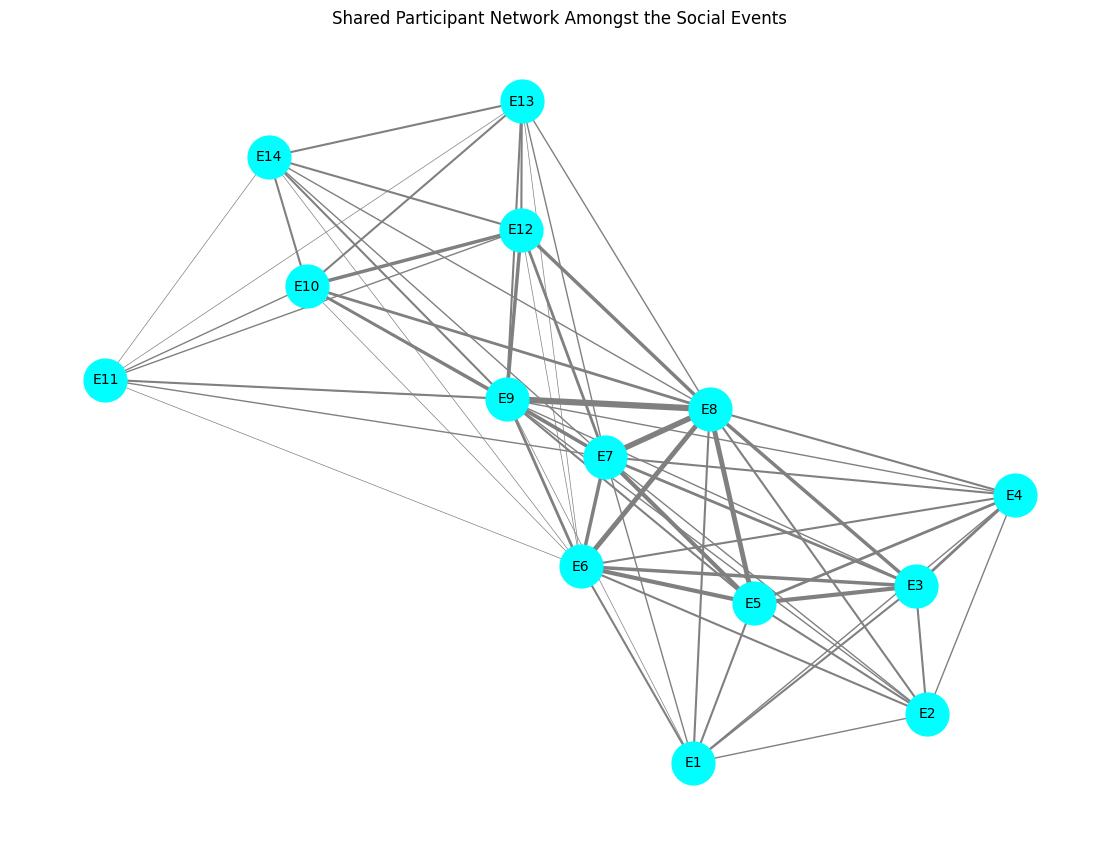

In [7]:
# Establish a reproducible layout for the events' projected network.
pos_events = nx.spring_layout(E, seed=648)

# Assign edge widths based on shared participants.
event_weights = [E[u][v]["weight"] for u, v in E.edges()]

# Visualize the event-to-event network.
plt.figure(figsize=(11, 8))

nx.draw(
    E,
    pos_events,
    with_labels=True,
    node_color="cyan",
    node_size=950,
    font_size=10,
    edge_color="gray",
    width=[weight * 0.5 for weight in event_weights]
)

plt.title("Shared Participant Network Amongst the Social Events")
plt.show()

###Interpretation

The projected event network comprises 14 social events with 66 shared attendance connections, resulting in a network density of 0.725. Events E8 and E9 share the greatest overlap with 9 common participants, followed by E7 and E8 (8) and several other pairs with 6 or more shared attendees. The visualization indicates a central cluster of highly interconnected events, suggesting that these events attracted similar groups of attendees/women. Events such as E11, E14, and E13 appear more peripheral within the visualization, suggesting relatively different patterns of shared attendance.

##**Conclusion**

The analysis of the Davis Southern Women dataset revealed substantial interconnectedness amongst both the women and their social events. With a projected network density of 0.908, the women exhibited extensive shared attendance, particularly Evelyn Jefferson and Theresa Anderson, who participated in 7 common events. Similarly, the event network demonstrated considerable overlap, with E8 and E9 sharing the greatest number of participants (9).

These findings suggest that certain women and social events played more prominent roles in facilitating shared social participation, whilst differences in attendance patterns indicate the possibility of distinct social groupings. However, it should be noted that shared attendance alone does not necessarily establish direct friendships, and the observed relationships should therefore be interpreted within the dataset's limitations.

##**References**

Davis, A., Gardner, B. B., & Gardner, M. R. (1941). *Deep South: A social anthropological study of caste and class*. University of Chicago Press.

NetworkX Developers. (n.d.). *Davis Southern Women Club*. NetworkX. https://networkx.org/documentation/stable/auto_examples/algorithms/plot_davis_club.html